In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve

from machineguard.modeling import(
    TARGET_COL,
    FEATURE_COLS,
    build_random_forest_model
)

In [3]:
DATA_PATH= "../data/ai4i2020.csv"
df = pd.read_csv(DATA_PATH)
X = df[FEATURE_COLS]
y = df[TARGET_COL]

In [6]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full
)

In [7]:
random_forest_model = build_random_forest_model()
random_forest_model.fit(X_train, y_train)

,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('category', ...), ('numeric', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [8]:
val_probabilities = random_forest_model.predict_proba(X_val)[:,1]
brier_score = brier_score_loss(y_val, val_probabilities)
brier_score

0.018179

In [9]:
prob_true , prob_pred = calibration_curve(
    y_val, val_probabilities, n_bins=5, strategy="quantile"
)

calibration_table = pd.DataFrame({
    "mean_predicted_probability":prob_pred,
    "actual_failure_rate":prob_true
})
calibration_table

,mean_predicted_probability,actual_failure_rate
0,0.000000,0.001631
1,0.007694,0.002591
2,0.152990,0.167526


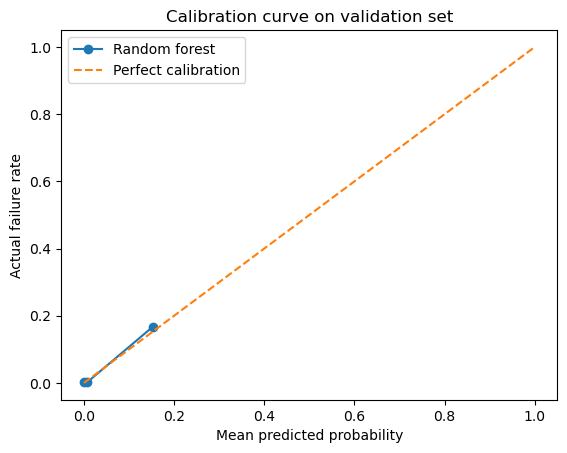

In [10]:
plt.plot(prob_pred, prob_true, marker="o", label="Random forest")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")

plt.xlabel("Mean predicted probability")
plt.ylabel("Actual failure rate")
plt.title("Calibration curve on validation set")
plt.legend()
plt.show()

- The calibration table groups machines by predicted failure probability.
- For low risk machines, the actual failure rate is also very low. For the higher risk group, the model predicts bout 15% faiure probability and the actual failure rate is about 17% which fairly close.